# Tutorial: Advanced Atomic Manipulation with QAtoms
QAtoms extends the popular ASE (Atomic Simulation Environment) library to provide a fluent, chainable interface for complex atomic manipulations. Its core philosophy relies on three principles:

- QAtoms is a child of ASE Atoms class, i.e. fully replacable

- Selection Mask: Operations apply only to currently selected atoms.

- Immutability: Every operation returns a modified copy; the original object remains unchanged.

# QAtoms

## Initialization and Basic Selection

You can initialize QAtoms by wrapping standard ASE objects or using the built-in bulk generators. By default, all atoms are selected upon creation.

In [1]:
from amstools import QAtoms
from ase.build import bulk

# Create a 2x2x2 Supercell of Aluminum
# Method 1: Using QAtoms factory
qat = QAtoms.bulk("Al", cubic=True) * (2, 2, 2)

# Method 2: Wrapping ASE Atoms
# qat = QAtoms(bulk("Al", cubic=True) * (2, 2, 2))

# Check selection (Default: 32 selected atoms)
qat

QAtoms(symbols='Al32', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 32 selected atoms)

### Random Sampling
To manipulate specific atoms, you often start by sampling a subset.

In [2]:
# Randomly select 1 atom. 
# The returned object has the same structure, but the internal mask selects only 1 atom.
r = qat.sample(n=1, random_state=42)
r

QAtoms(symbols='Al32', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 1 selected atoms)

## Chainable Manipulations (The Fluent Interface)
The power of QAtoms lies in chaining methods. You can select, modify, and re-select in a single line.

### Substitution & Nearest Neighbors
This example selects an atom, changes it to Lithium, finds its neighbors, and modifies them.

In [3]:
# 1. Sample 1 atom
# 2. Change it to 'Li'
# 3. Select nearest neighbors (nn)
# 4. Change neighbors to 'Ni'
# 5. Select atoms within 3 Angstroms
# 6. Change those to 'Cu'

complex_structure = (
    qat
    .sample(n=1, random_state=1)
    .set(element="Li")
    .select_nn()
    .set(element="Ni")
    .select_nearby(cutoff=3)
    .set(element="Cu")
)

In [4]:
complex_structure

QAtoms(symbols='Al3CuAl6Cu2Al2CuAl2CuAlCuAlCuAl2NiCu3AlCu2Al', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 12 selected atoms)

### Deletion
You can also identify patterns and remove atoms easily.

In [5]:
# Select 1 atom -> Turn to Li -> Find 2 nearest neighbors -> Delete them
defect = qat.sample(n=1, random_state=42).set(element="Li").select_nn(n=2).delete()

In [6]:
defect

QAtoms(symbols='Al28LiAl', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 0 selected atoms)

## Advanced Geometry: Interstitials
QAtoms simplifies the complex math of placing interstitial atoms. It attempts to place new atoms within a cutoff distance of the current selection while maintaining a minimum distance from any atom.

In [7]:
# 1. Select 1 random atom
# 2. Add 'H' nearby (max 2.5A away, min 1.0A from neighbors)
# 3. 'select_new=True' moves the selection mask to the newly added H atom
r = qat.sample(n=1, random_state=42)
structure_with_H = r.insert_interstitial(
    element='H', 
    cutoff=2.5, 
    min_dist=1.0, 
    max_attempts=100, 
    select_new=True
)

In [8]:
structure_with_H.view()

Pro Tip: You can chain insertions to build clusters.

In [9]:
# Insert H, keep selection on Li (select_new=False), then insert another H
Al_Li_H2 = (
    r.set(element='Li')
    .insert_interstitial(element='H', select_new=False)
    .insert_interstitial(element='H')
)

In [10]:
Al_Li_H2

QAtoms(symbols='Al29LiAl2H2', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 1 selected atoms)

In [11]:
Al_Li_H2.view()

## Working with Surfaces (Tags)
ASE typically uses "tags" to denote surface layers. QAtoms can filter by these tags.

In [12]:
from ase.build import fcc100

# Create a slab with vacuum
surf = QAtoms(fcc100('Al', (2,2,5), periodic=True, vacuum=10))

# Select only the top layer (Tag 5 in ASE default generation)
q_surf = surf.select(tag=5)

# Create a supercell (Selection mask expands automatically)
q_surf_supercell = q_surf * (2, 2, 1)

# Complex Logic:
# Select 1 surface atom -> Make it Ni -> Select nearby atoms -> 
# Filter ONLY those nearby atoms that are ALSO surface atoms (tag=5) -> Make them Li
result = (
    q_surf_supercell
    .sample(n=1)
    .set(element='Ni')
    .select_nearby(cutoff=3)
    .select(tag=5)
    .set(element='Li')
)

In [13]:
result.view()

## Advanced Selection Utilities

Beyond simple sampling and nearest-neighbor searches, `QAtoms` provides granular control over the selection mask.

### Predicate Filtering (`filter`)

When tags or elements aren't enough, you can use `filter()` with a custom Python function (lambda) that runs on every `ase.Atom`.

In [14]:
# Select atoms that are 'Al' AND have a Z-coordinate greater than 10.0
# The lambda receives an ase.Atom object 'a'
top_layer = qat.all().filter(lambda a: a.symbol == 'Al' and a.position[2] > 6)

In [15]:
top_layer=top_layer.set(element='Li')

In [16]:
top_layer

QAtoms(symbols='Al5Li2Al6Li2Al6Li2Al6Li2Al', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 8 selected atoms)

In [17]:
top_layer.view()

### Inverting and Resetting

You can quickly flip the selection or reset it entirely.

In [18]:
# Selects everything NOT currently selected
inverted = top_layer.invert_selection()
inverted

QAtoms(symbols='Al5Li2Al6Li2Al6Li2Al6Li2Al', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 24 selected atoms)

In [19]:
# Selects ALL atoms (reset)
all_selected = qat.all()

In [20]:
# Deselects everything (useful before running additive selections)
none_selected = qat.clear()

## Geometric Transformations

### Precise Atomic Shifting (`shift_atoms`)

You can move *selected* atoms by a specific vector. This supports both Cartesian (Angstroms) and Fractional (scaled) coordinates.

In [21]:
qat = qat.select_explicitly(selection_inds=0)
qat

QAtoms(symbols='Al32', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 1 selected atoms)

In [22]:
qat.positions[0]

array([0., 0., 0.])

In [23]:
# Shift selected atoms by 0.5 Angstrom in the X direction
shifted_cart = qat.shift_atoms(shift=[0.5, 0, 0])
shifted_cart.positions[0]

array([0.5, 0. , 0. ])

In [24]:
# Shift selected atoms by half a unit cell in the Z direction (Fractional)
# 'wrap=True' ensures atoms stay inside the simulation box
shifted_frac = qat.shift_atoms(scaled_shift=[0, 0, 0.5], wrap=True)
shifted_frac.positions[0]

array([0.  , 0.  , 4.05])

### Dictionary-Based Substitution (`substitute`)

While `.set(element=...)` sets all selected atoms to a *single* element, `.substitute()` allows you to map multiple elements simultaneously within the current selection.

In [25]:
# Within the current selection:
# Change all Aluminum to Silicon
# Change all Oxygen to Nitrogen
swapped = qat.all().substitute({'Al': 'Si', 'O': 'N'})
swapped

QAtoms(symbols='Si32', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 32 selected atoms)

## Physics and Optimization

`QAtoms` includes wrappers for geometry optimization (relaxation) and analysis, integrating directly with ASE's calculators.

### Geometry Optimization (`relax` / `full_relax`)

These methods run a BFGS optimization on the structure.

* `relax()`: Optimizes atomic positions only (fixed cell).
* `full_relax()`: Optimizes positions **and** cell vectors (variable cell) using `FrechetCellFilter`.

In [26]:
from ase.calculators.emt import EMT

In [27]:
# Requires a calculator to be attached!
qat.calc = EMT()

In [28]:
# Relax atoms until forces are below 0.05 eV/A
relaxed_structure = qat.relax(fmax=0.05)

      Step     Time          Energy          fmax
BFGS:    0 00:43:19       -0.048066        0.000000


In [29]:
# Relax atoms AND cell dimensions
fully_relaxed = qat.full_relax(fmax=0.01)


      Step     Time          Energy          fmax
BFGS:    0 00:43:20       -0.048066        0.161794
BFGS:    1 00:43:20       -0.049185        0.160965
BFGS:    2 00:43:20       -0.124122        0.088624
BFGS:    3 00:43:20       -0.155311        0.015179
BFGS:    4 00:43:20       -0.156246        0.000106


### Radial Distribution Function (`compute_rdf`)

You can quickly analyze the structure by computing the RDF for the *selected* atoms.

In [30]:
# Compute RDF between selected atoms and all other atoms
# Returns a dictionary of data
rdf_data = qat.all().compute_rdf(element_pairs=[('Al', 'Al')], max_range=10.0)
rdf_data

{('Al',
  'Al'): {'r': array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5,
         2.7, 2.9, 3.1, 3.3, 3.5, 3.7, 3.9, 4.1, 4.3, 4.5, 4.7, 4.9, 5.1,
         5.3, 5.5, 5.7, 5.9, 6.1, 6.3, 6.5, 6.7, 6.9, 7.1, 7.3, 7.5, 7.7,
         7.9, 8.1, 8.3, 8.5, 8.7, 8.9, 9.1, 9.3, 9.5, 9.7, 9.9]), 'g_r': array([0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 9.73282139,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         2.43465282, 0.        , 0.        , 0.        , 6.81824472,
         0.        , 0.        , 0.        , 2.51932988, 0.        ,
         0.        , 0.        , 3.87469954, 0.        , 0.        ,
         1.08249723, 0.        , 5.82065976, 0.        , 0.        ,
         0.6237847 , 0.        , 3.39874164, 0.        , 0.        ,
         1.97688752, 0.        , 1.81391751, 0.        , 1.670299

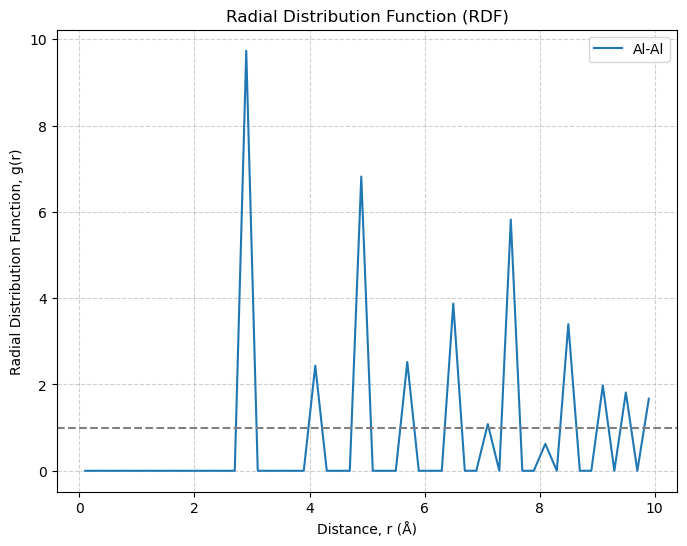

In [31]:
# Plot it directly (requires matplotlib)
qat.all().plot_rdf(element_pairs=[('Al', 'Al')])

## Metadata and File I/O

### Naming (`name`)

When generating datasets, tracking the history of a structure is vital. The `.name()` method appends a string to the `info['name']` attribute.

In [32]:
qat = QAtoms.bulk('Al', cubic=True).name('bulk_Al')*(2,2,2)
qat

QAtoms(symbols='Al32', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 32 selected atoms)

In [33]:
qat.info

{'name': 'bulk_Al'}

In [34]:
# If original name was "bulk_Al"
# New name becomes "bulk_Al/defect_H"
named_struct = qat.sample(n=1, random_state=42).delete().name("defect_H")
named_struct, named_struct.info

(QAtoms(symbols='Al31', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 0 selected atoms),
 {'name': 'bulk_Al/defect_H'})

In [35]:
# You can also use a function to generate the name dynamically
# e.g., appending the number of atoms
named_dynamic = qat.name(lambda a: f"size_{len(a)}")
named_dynamic.info

{'name': 'bulk_Al/size_32'}

### Composition (`comp_dict`)

A helper property to quickly check the chemical formula of your structure.

In [36]:
# Returns a Counter, e.g., Counter({'Al': 31, 'Li': 1})
qat.comp_dict


Counter({'Al': 32})

### Direct Reading (`read`)

A static method to load files directly as `QAtoms`, avoiding the need to import `ase.io.read`.

```python
# Load a file directly into QAtoms
qat_from_file = QAtoms.read("structure.xyz")

```

# QAtomsCollection

In [37]:
from amstools import QAtoms, QAtomsCollection

# 1. Initialize and Name
#    Create 2x2x2 Al supercell and set base name.
#   
qat = QAtoms.bulk("Al", cubic=True).repeat((2, 2, 2)).name("Al_bulk")

qat

QAtoms(symbols='Al32', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 32 selected atoms)

In [38]:
# 2. Break Symmetry (Create Alloy)
#    Select 50% of atoms and change to Li.
#    Append "/AlLi" to the name.
alloy = (
    qat
    .sample(frac=0.5, random_state=42)
    .set(element="Li")
    .name("AlLi")
)
alloy

QAtoms(symbols='LiAl3Li2Al2Li2AlLi3AlLi3Al5Li3Al3Li2Al', pbc=True, cell=[8.1, 8.1, 8.1], _selected_mask=..., 16 selected atoms)

In [40]:
# 3. Create Collection and Generate Vacancies
#    We wrap the alloy in a collection to start the branching process.
vacancy_collection = (
    alloy
    .all()                         # Reset selection to include ALL atoms (Al and Li)
    .sample(n=3, random_state=99)  # Select 3 atoms "from scratch" to be vacancy candidates
    .flat()                        # Split: Creates 3 separate structures, each with 1 atom selected
    .delete()                      # Apply deletion to the selected atom in each structure
    .map(lambda q: q.name("vac"))                   # Append "/vac" to the name of all resulting structures
)

In [41]:
vacancy_collection

QAtomsCollection(3 structures)

In [42]:
# 4. Verify Results
print(f"Created {len(vacancy_collection)} structures.")

for i, struct in enumerate(vacancy_collection):
    # Print the automatically generated name and composition
    print(f"Structure {i+1}: {struct.info['name']}")
    print(f"   Composition: {struct.comp_dict}")
    print(f"   Total Atoms: {len(struct)}")

Created 3 structures.
Structure 1: Al_bulk/AlLi/vac
   Composition: Counter({'Al': 16, 'Li': 15})
   Total Atoms: 31
Structure 2: Al_bulk/AlLi/vac
   Composition: Counter({'Al': 16, 'Li': 15})
   Total Atoms: 31
Structure 3: Al_bulk/AlLi/vac
   Composition: Counter({'Li': 16, 'Al': 15})
   Total Atoms: 31


In [44]:
vacancy_collection.view()

2026-01-14 00:44:32.966 python[79357:23957052] +[IMKClient subclass]: chose IMKClient_Modern
2026-01-14 00:44:32.966 python[79357:23957052] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [46]:
df=vacancy_collection.to_pandas()
df

,ase_atoms,name
0,"(Atom('Li', [0.0, 0.0, 0.0], index=0), Atom('A...",Al_bulk/AlLi/vac
1,"(Atom('Li', [0.0, 0.0, 0.0], index=0), Atom('A...",Al_bulk/AlLi/vac
2,"(Atom('Li', [0.0, 0.0, 0.0], index=0), Atom('A...",Al_bulk/AlLi/vac
